100.0%
100.0%
100.0%
100.0%


[Baseline] Epoch 1 | Accuracy: 96.32%
[Baseline] Epoch 2 | Accuracy: 97.06%
[Baseline] Epoch 3 | Accuracy: 97.61%
[DP σ=0.5] Epoch 1 | Accuracy: 88.37% | ε: 0.2216
[DP σ=0.5] Epoch 2 | Accuracy: 89.79% | ε: 0.3134
[DP σ=0.5] Epoch 3 | Accuracy: 90.44% | ε: 0.3839
[DP σ=1.0] Epoch 1 | Accuracy: 86.41% | ε: 0.1108
[DP σ=1.0] Epoch 2 | Accuracy: 88.35% | ε: 0.1567
[DP σ=1.0] Epoch 3 | Accuracy: 87.72% | ε: 0.1919
[DP σ=2.0] Epoch 1 | Accuracy: 78.18% | ε: 0.0554
[DP σ=2.0] Epoch 2 | Accuracy: 77.88% | ε: 0.0784
[DP σ=2.0] Epoch 3 | Accuracy: 77.96% | ε: 0.0960


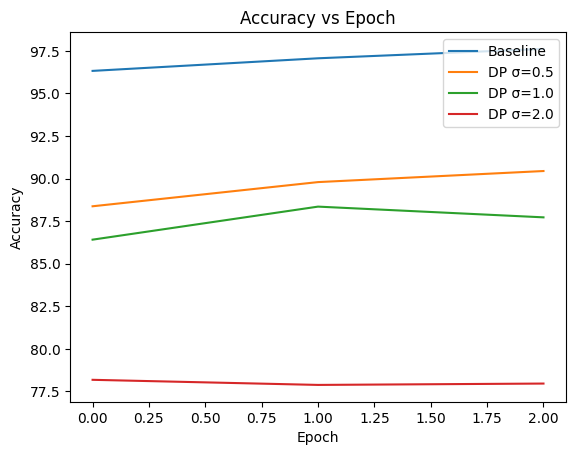

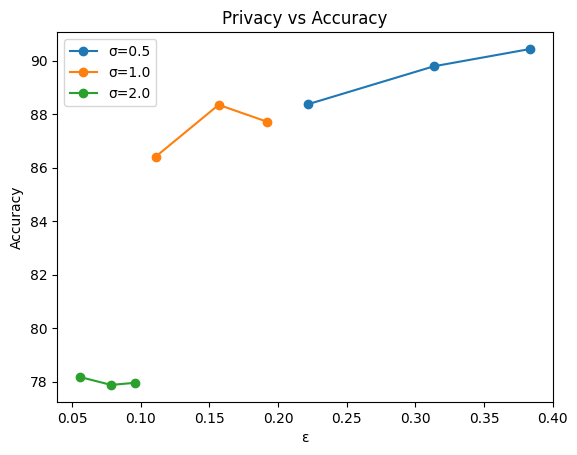

In [ ]:
# =========================================================
# DP-SGD IMPLEMENTATION
# =========================================================

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import math
import matplotlib.pyplot as plt
from PIL import Image


# =========================================================
# CONFIGURATION
# =========================================================
class Config:
    DATA_PATH = "./data"
    BATCH_SIZE = 32
    TEST_BATCH_SIZE = 64
    LEARNING_RATE = 0.05
    CLIP_NORM = 1.0
    NOISE_MULTIPLIERS = [0.5, 1.0, 2.0]
    EPOCHS = 3
    DELTA = 1e-5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# DATA LOADER
# =========================================================
class MNISTLoader:
    def __init__(self, config):
        self.config = config
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

    def get_loaders(self):
        train_dataset = datasets.MNIST(
            root=self.config.DATA_PATH,
            train=True,
            download=True,
            transform=self.transform
        )

        test_dataset = datasets.MNIST(
            root=self.config.DATA_PATH,
            train=False,
            download=True,
            transform=self.transform
        )

        train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=True
        )

        test_loader = torch.utils.data.DataLoader(
            test_dataset,
            batch_size=self.config.TEST_BATCH_SIZE,
            shuffle=False
        )

        return train_dataset, train_loader, test_loader


# =========================================================
# MODEL
# =========================================================
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


# =========================================================
# TRAINER
# =========================================================
class DPSGDTrainer:
    def __init__(self, config, train_dataset, train_loader, test_loader):
        self.config = config
        self.train_dataset = train_dataset
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = nn.CrossEntropyLoss()

    # -------------------------
    # Evaluation
    # -------------------------
    def evaluate(self, model):
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for data, target in self.test_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)
                output = model(data)
                pred = output.argmax(dim=1)

                correct += (pred == target).sum().item()
                total += target.size(0)

        return 100 * correct / total

    # -------------------------
    # Per-sample gradients
    # -------------------------
    def compute_per_sample_gradients(self, model, data, target):
        grads = []

        for i in range(len(data)):
            model.zero_grad(set_to_none=True)

            output = model(data[i].unsqueeze(0))
            loss = self.criterion(output, target[i].unsqueeze(0))
            loss.backward()

            grads.append([p.grad.detach().clone() for p in model.parameters()])

        return grads

    # -------------------------
    # Gradient clipping
    # -------------------------
    def clip_gradients(self, gradients):
        clipped = []

        for grad_list in gradients:
            total_norm = torch.sqrt(sum([g.norm() ** 2 for g in grad_list]))
            scale = min(1.0, self.config.CLIP_NORM / (total_norm + 1e-6))
            clipped.append([g * scale for g in grad_list])

        return clipped

    # -------------------------
    # Add Gaussian noise
    # -------------------------
    def add_noise(self, gradients, sigma):
        batch_size = len(gradients)
        noisy_grads = []

        for i in range(len(gradients[0])):
            stacked = torch.stack([g[i] for g in gradients])
            avg_grad = torch.mean(stacked, dim=0)

            noise = torch.normal(
                mean=0,
                std=sigma * self.config.CLIP_NORM,
                size=avg_grad.shape,
                device=avg_grad.device
            )

            noisy_grads.append(avg_grad + noise / batch_size)

        return noisy_grads

    # -------------------------
    # Update model
    # -------------------------
    def update_model(self, model, grads):
        with torch.no_grad():
            for p, g in zip(model.parameters(), grads):
                p -= self.config.LEARNING_RATE * g

    # -------------------------
    # Privacy calculation
    # -------------------------
    def compute_epsilon(self, epoch, sigma):
        q = self.config.BATCH_SIZE / len(self.train_dataset)
        T = (epoch + 1) * len(self.train_loader)

        return (q * math.sqrt(2 * T * math.log(1 / self.config.DELTA))) / sigma

    # -------------------------
    # Baseline training
    # -------------------------
    def train_baseline(self):
        model = DigitClassifier().to(self.config.DEVICE)
        optimizer = torch.optim.SGD(model.parameters(), lr=self.config.LEARNING_RATE)

        acc_history = []

        for epoch in range(self.config.EPOCHS):
            model.train()

            for data, target in self.train_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                optimizer.zero_grad()
                output = model(data)
                loss = self.criterion(output, target)
                loss.backward()
                optimizer.step()

            acc = self.evaluate(model)
            acc_history.append(acc)

            print(f"[Baseline] Epoch {epoch+1} | Accuracy: {acc:.2f}%")

        return model, acc_history

    # -------------------------
    # DP training
    # -------------------------
    def train_dp(self, sigma):
        model = DigitClassifier().to(self.config.DEVICE)

        acc_history = []
        eps_history = []

        for epoch in range(self.config.EPOCHS):
            model.train()

            for data, target in self.train_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                grads = self.compute_per_sample_gradients(model, data, target)
                grads = self.clip_gradients(grads)
                grads = self.add_noise(grads, sigma)
                self.update_model(model, grads)

            acc = self.evaluate(model)
            eps = self.compute_epsilon(epoch, sigma)

            acc_history.append(acc)
            eps_history.append(eps)

            print(f"[DP σ={sigma}] Epoch {epoch+1} | Accuracy: {acc:.2f}% | ε: {eps:.4f}")

        return model, acc_history, eps_history


# =========================================================
# PLOTTING
# =========================================================
class Plotter:
    @staticmethod
    def plot_accuracy(baseline_acc, dp_results):
        plt.figure()
        plt.plot(baseline_acc, label="Baseline")

        for sigma, (acc, _) in dp_results.items():
            plt.plot(acc, label=f"DP σ={sigma}")

        plt.legend()
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy vs Epoch")
        plt.show()

    @staticmethod
    def plot_privacy(dp_results):
        plt.figure()

        for sigma, (acc, eps) in dp_results.items():
            plt.plot(eps, acc, marker='o', label=f"σ={sigma}")

        plt.xlabel("ε")
        plt.ylabel("Accuracy")
        plt.title("Privacy vs Accuracy")
        plt.legend()
        plt.show()


# =========================================================
# PREDICTOR
# =========================================================
class Predictor:
    def __init__(self, model, config):
        self.model = model
        self.device = config.DEVICE

    def predict(self, image_path):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

        img = Image.open(image_path).convert("L").resize((28, 28))
        img = transform(img).unsqueeze(0).to(self.device)

        with torch.no_grad():
            pred = self.model(img).argmax(dim=1).item()

        plt.imshow(img.cpu().squeeze(), cmap='gray')
        plt.title(f"Prediction: {pred}")
        plt.axis("off")
        plt.show()

        return pred


# =========================================================
# MAIN
# =========================================================
def main():
    config = Config()

    loader = MNISTLoader(config)
    train_dataset, train_loader, test_loader = loader.get_loaders()

    trainer = DPSGDTrainer(config, train_dataset, train_loader, test_loader)

    # Baseline
    baseline_model, baseline_acc = trainer.train_baseline()

    # DP experiments
    dp_results = {}
    final_model = None

    for sigma in config.NOISE_MULTIPLIERS:
        model, acc, eps = trainer.train_dp(sigma)
        dp_results[sigma] = (acc, eps)
        final_model = model

    # Plot
    Plotter.plot_accuracy(baseline_acc, dp_results)
    Plotter.plot_privacy(dp_results)

    # Predict
    predictor = Predictor(final_model, config)
    #predictor.predict("/content/drive/MyDrive/test.png")


if __name__ == "__main__":
    main()